# ⚙️ Notebook 2 — Feature Engineering
**Project:** Real-Time Customer Churn Analysis Agent  
**Input:** `data/telco_churn_clean.csv`  
**Output:** `data/telco_churn_features.csv` + `data/feature_metadata.json`

### What this notebook does
| Step | Technique |
|------|-----------|
| Encode binary categoricals | Map Yes/No → 1/0 |
| Encode multi-class categoricals | One-hot encoding |
| Engineer new domain features | tenure buckets, charge ratios, service counts, risk score |
| Scale numeric features | StandardScaler (saved for inference reuse) |
| Feature importance preview | Quick Random Forest importance plot |
| Save artefacts | Feature CSV + scaler pickle + metadata JSON |

---
### Table of Contents
1. [Imports & Load](#1)
2. [Encode Binary Columns](#2)
3. [Encode Multi-Class Columns](#3)
4. [Engineer New Features](#4)
5. [Scale Numeric Features](#5)
6. [Feature Importance Preview](#6)
7. [Save Artefacts](#7)

---
## 1. Imports & Load <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, pickle, warnings

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/telco_churn_clean.csv')
print(f'Loaded  →  {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Loaded  →  7,021 rows × 20 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


---
## 2. Encode Binary Columns <a id='2'></a>

All Yes/No and Male/Female columns become **1 / 0** integers.

In [2]:
df_fe = df.copy()

# ── binary string columns ──────────────────────────────────────────────────────
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling', 'Churn'
]

binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}

for col in binary_cols:
    df_fe[col] = df_fe[col].map(binary_map)

# SeniorCitizen is already 0/1 int — nothing to do

print('Binary encoding done.')
df_fe[binary_cols].head(4)

Binary encoding done.


,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,0,1,0,0,1,0
1,1,0,0,1,0,0
2,1,0,0,1,1,1
3,1,0,0,0,0,0


---
## 3. Encode Multi-Class Columns <a id='3'></a>

Columns with 3+ categories get **one-hot encoded** (drop_first=True to avoid dummy trap).

In [3]:
# columns with 3+ unique values (excluding binary ones already handled)
multi_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

df_fe = pd.get_dummies(df_fe, columns=multi_cols, drop_first=True, dtype=int)

print(f'Shape after one-hot encoding: {df_fe.shape}')
print('New columns added:')
new_cols = [c for c in df_fe.columns if any(m in c for m in multi_cols)]
print(new_cols)

Shape after one-hot encoding: (7021, 31)
New columns added:
['MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


---
## 4. Engineer New Features <a id='4'></a>

Domain-driven features that consistently improve churn model performance in the literature.

| Feature | Formula / Logic | Intuition |
|---------|----------------|-----------|
| `charges_per_month_ratio` | MonthlyCharges / (TotalCharges + 1) | High ratio → customer is new; low ratio → long loyal customer |
| `avg_monthly_spend` | TotalCharges / (tenure + 1) | Average spend normalised by tenure |
| `tenure_group` | Bucketed (0–12, 13–24, …) | Captures non-linear tenure effect |
| `num_services` | Sum of 8 service flags | More services → stickier customer |
| `has_streaming` | StreamingTV OR StreamingMovies | Entertainment commitment |
| `has_support` | TechSupport OR OnlineSecurity | Support engagement |
| `is_month_to_month` | Contract == Month-to-month | Biggest churn predictor |
| `auto_payment` | PaymentMethod is bank/credit auto | Friction-reducing payment → lower churn |
| `risk_score` | Weighted composite heuristic | Quick interpretable risk proxy |

In [4]:
# ── 4.1  Charge ratios ────────────────────────────────────────────────────────
df_fe['charges_per_month_ratio'] = (
    df_fe['MonthlyCharges'] / (df_fe['TotalCharges'] + 1)
).round(4)

df_fe['avg_monthly_spend'] = (
    df_fe['TotalCharges'] / (df_fe['tenure'] + 1)
).round(4)

# ── 4.2  Tenure group (ordinal) ───────────────────────────────────────────────
tenure_bins   = [0, 12, 24, 36, 48, 60, 72]
tenure_labels = [1, 2, 3, 4, 5, 6]           # ordinal integers
df_fe['tenure_group'] = pd.cut(
    df_fe['tenure'], bins=tenure_bins, labels=tenure_labels, include_lowest=True
).astype(int)

print('Charge ratios and tenure group created ✔')

Charge ratios and tenure group created ✔


In [5]:
# ── 4.3  Service count ────────────────────────────────────────────────────────
# after one-hot, service columns contain '_Yes' suffix
service_flag_cols = [
    c for c in df_fe.columns
    if any(s in c for s in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                             'TechSupport', 'StreamingTV', 'StreamingMovies',
                             'MultipleLines'])
    and c.endswith('_Yes')
]

df_fe['num_services'] = df_fe[service_flag_cols].sum(axis=1)
print(f'Service flag columns used ({len(service_flag_cols)}): {service_flag_cols}')
print('num_services distribution:')
print(df_fe['num_services'].value_counts().sort_index().to_dict())

Service flag columns used (7): ['MultipleLines_Yes', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']
num_services distribution:
{0: 1645, 1: 1158, 2: 957, 3: 978, 4: 933, 5: 722, 6: 420, 7: 208}


In [6]:
# ── 4.4  Streaming & support flags ───────────────────────────────────────────
streaming_cols = [c for c in df_fe.columns if 'Streaming' in c and c.endswith('_Yes')]
support_cols   = [c for c in df_fe.columns if ('TechSupport' in c or 'OnlineSecurity' in c)
                  and c.endswith('_Yes')]

df_fe['has_streaming'] = (df_fe[streaming_cols].sum(axis=1) > 0).astype(int)
df_fe['has_support']   = (df_fe[support_cols].sum(axis=1) > 0).astype(int)

print('has_streaming:', df_fe['has_streaming'].value_counts().to_dict())
print('has_support  :', df_fe['has_support'].value_counts().to_dict())

has_streaming: {0: 3522, 1: 3499}
has_support  : {0: 4057, 1: 2964}


In [7]:
# ── 4.5  Contract & payment convenience flags ─────────────────────────────────
# after get_dummies(drop_first=True), 'Contract_Month-to-month' is the reference;
# so its absence of Two year / One year flags implies month-to-month

two_yr_col  = [c for c in df_fe.columns if 'Two year'  in c]
one_yr_col  = [c for c in df_fe.columns if 'One year'  in c]

if two_yr_col and one_yr_col:
    df_fe['is_month_to_month'] = (
        (df_fe[two_yr_col[0]] == 0) & (df_fe[one_yr_col[0]] == 0)
    ).astype(int)
else:
    # fallback if column names differ
    df_fe['is_month_to_month'] = 0
    print('⚠ Could not locate Contract dummy columns — check get_dummies output above.')

# auto-payment: bank transfer or credit card
auto_pay_cols = [c for c in df_fe.columns
                 if 'Bank transfer' in c or 'Credit card' in c]
if auto_pay_cols:
    df_fe['auto_payment'] = (df_fe[auto_pay_cols].sum(axis=1) > 0).astype(int)
else:
    df_fe['auto_payment'] = 0

print('is_month_to_month:', df_fe['is_month_to_month'].value_counts().to_dict())
print('auto_payment     :', df_fe['auto_payment'].value_counts().to_dict())

is_month_to_month: {1: 3853, 0: 3168}
auto_payment     : {0: 5499, 1: 1522}


In [8]:
# ── 4.6  Composite risk score (interpretable heuristic) ──────────────────────
# Each weight is directionally motivated by the correlation analysis from NB1
df_fe['risk_score'] = (
    0.30 * df_fe['is_month_to_month'] +          # biggest single driver
    0.20 * (1 - df_fe['tenure_group'] / 6) +     # newer → higher risk
    0.15 * df_fe['charges_per_month_ratio'] +     # high ratio → newer
    0.15 * (1 - df_fe['has_support'].clip(0,1)) + # no support → higher risk
    0.10 * (1 - df_fe['auto_payment']) +           # manual payment → higher risk
    0.10 * (1 - df_fe['num_services'] / 7)        # fewer services → higher risk
).round(4)

print('risk_score stats:')
print(df_fe['risk_score'].describe().round(3))

risk_score stats:
count    7021.000
mean        0.521
std         0.394
min         0.002
25%         0.252
50%         0.533
75%         0.763
max        12.423
Name: risk_score, dtype: float64


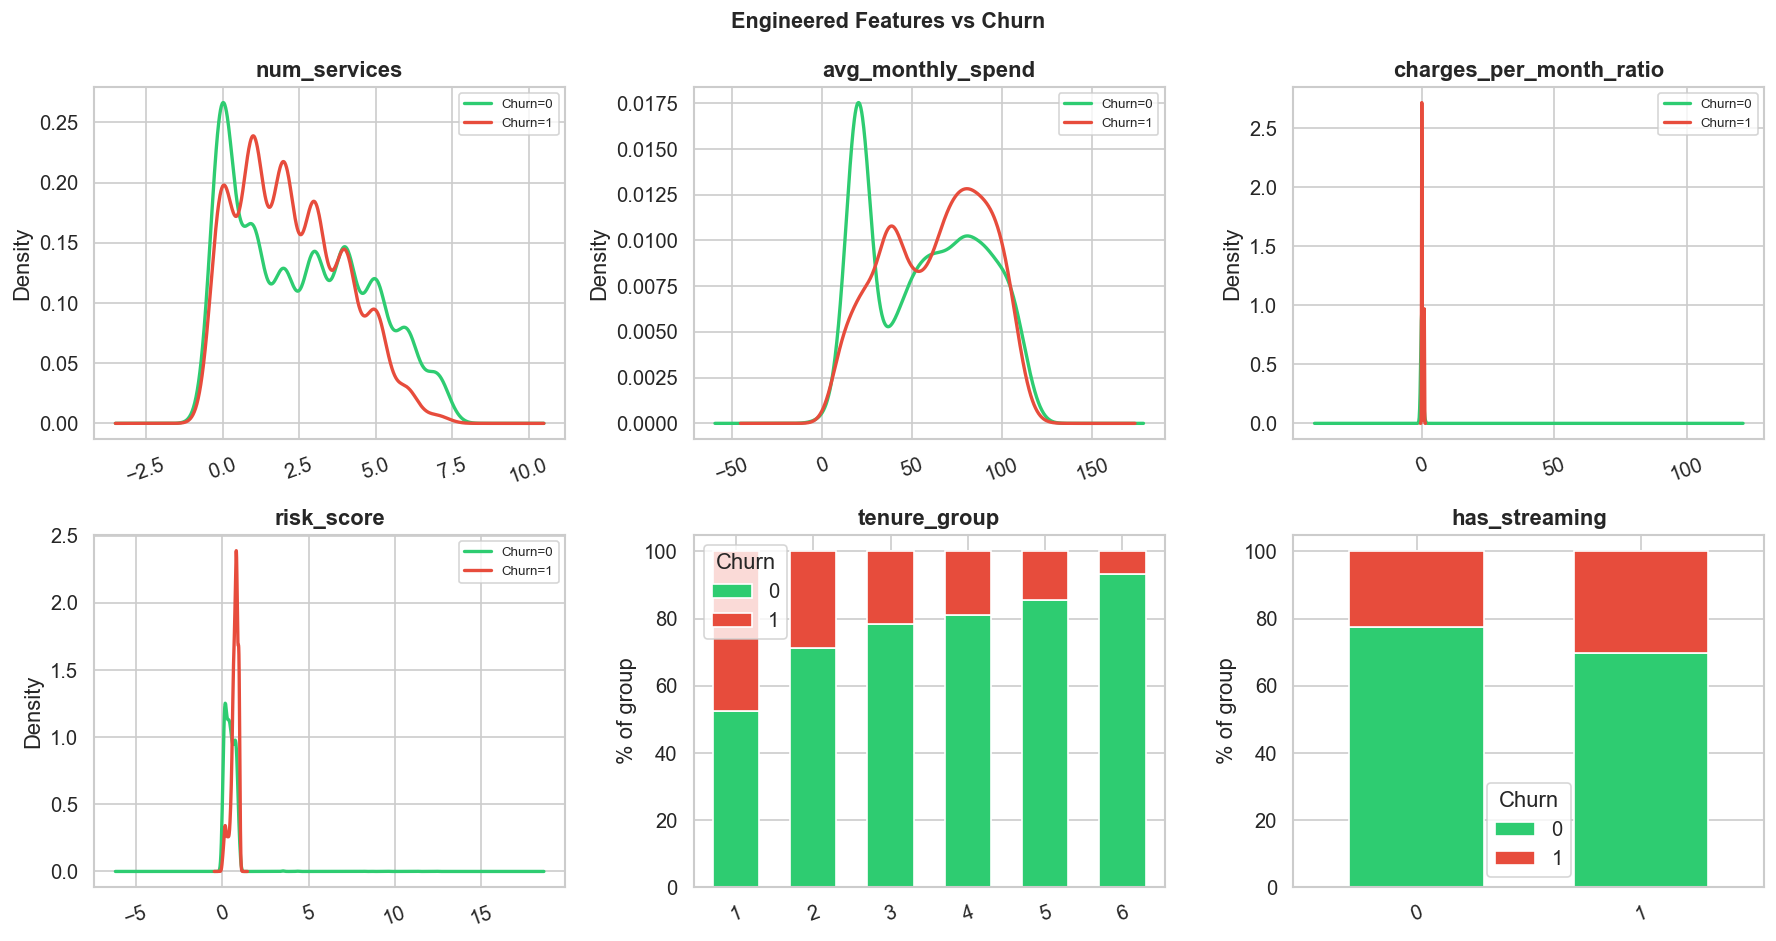

In [9]:
# ── 4.7  Visualise engineered features vs Churn ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plot_feats = ['num_services', 'avg_monthly_spend',
              'charges_per_month_ratio', 'risk_score',
              'tenure_group', 'has_streaming']
palette = {1: '#e74c3c', 0: '#2ecc71'}

for ax, feat in zip(axes.flatten(), plot_feats):
    if df_fe[feat].nunique() <= 7:          # discrete → bar
        ct = pd.crosstab(df_fe[feat], df_fe['Churn'], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, ax=ax,
                color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.6)
        ax.set_ylabel('% of group')
        ax.set_xlabel('')
    else:                                   # continuous → KDE
        for label, grp in df_fe.groupby('Churn'):
            color = '#e74c3c' if label == 1 else '#2ecc71'
            grp[feat].plot.kde(ax=ax, label=f'Churn={label}',
                               color=color, linewidth=2)
        ax.legend(fontsize=8)
    ax.set_title(feat, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Engineered Features vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Scale Numeric Features <a id='5'></a>

Tree models don't need scaling, but **Logistic Regression / SVM / Neural Nets** do.  
We scale here and save the scaler so the real-time pipeline can apply the same transform.

In [10]:
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
              'avg_monthly_spend', 'charges_per_month_ratio', 'risk_score']

scaler = StandardScaler()
df_fe[scale_cols] = scaler.fit_transform(df_fe[scale_cols])

print('Scaled columns:', scale_cols)
df_fe[scale_cols].describe().round(3)

Scaled columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'charges_per_month_ratio', 'risk_score']


,tenure,MonthlyCharges,TotalCharges,avg_monthly_spend,charges_per_month_ratio,risk_score
count,7021.000,7021.000,7021.000,7021.000,7021.000,7021.000
mean,0.000,-0.000,-0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.323,-1.550,-1.009,-1.936,-0.109,-1.317
25%,-0.957,-0.968,-0.831,-1.076,-0.106,-0.681
50%,-0.141,0.185,-0.391,0.067,-0.097,0.031
75%,0.918,0.833,0.668,0.844,-0.056,0.615
max,1.611,1.793,2.823,1.960,42.819,30.206


---
## 6. Feature Importance Preview <a id='6'></a>

Quick sanity check — fit a shallow Random Forest and plot top-20 importances.  
Full modelling is in `03_churn_prediction_model.ipynb`.

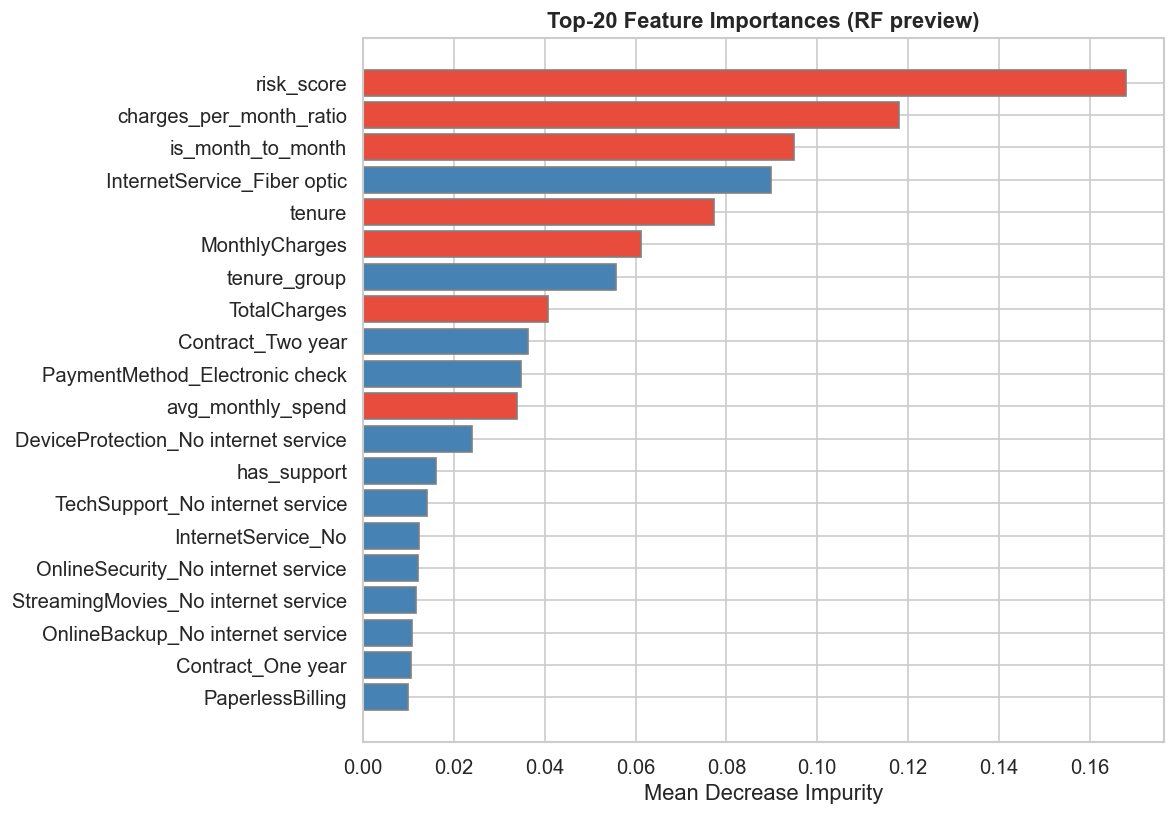


Top 10 features:
                       feature  importance
                    risk_score    0.168017
       charges_per_month_ratio    0.118015
             is_month_to_month    0.094866
   InternetService_Fiber optic    0.089884
                        tenure    0.077206
                MonthlyCharges    0.061115
                  tenure_group    0.055751
                  TotalCharges    0.040803
             Contract_Two year    0.036365
PaymentMethod_Electronic check    0.034868


In [11]:
X = df_fe.drop(columns='Churn')
y = df_fe['Churn']

rf_preview = RandomForestClassifier(n_estimators=100, max_depth=6,
                                     random_state=42, n_jobs=-1)
rf_preview.fit(X, y)

importance_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': rf_preview.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if f in ['tenure', 'MonthlyCharges', 'TotalCharges',
                               'avg_monthly_spend', 'charges_per_month_ratio',
                               'risk_score', 'num_services', 'is_month_to_month']
          else 'steelblue'
          for f in importance_df['feature']]

plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
         color=colors[::-1], edgecolor='grey')
plt.xlabel('Mean Decrease Impurity')
plt.title('Top-20 Feature Importances (RF preview)', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(importance_df.head(10).to_string(index=False))

### 6.1 Final feature list

In [12]:
print(f'Total features going into modelling : {X.shape[1]}')
print('\nAll feature names:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:>2}. {col}')

Total features going into modelling : 39

All feature names:
   1. gender
   2. SeniorCitizen
   3. Partner
   4. Dependents
   5. tenure
   6. PhoneService
   7. PaperlessBilling
   8. MonthlyCharges
   9. TotalCharges
  10. MultipleLines_No phone service
  11. MultipleLines_Yes
  12. InternetService_Fiber optic
  13. InternetService_No
  14. OnlineSecurity_No internet service
  15. OnlineSecurity_Yes
  16. OnlineBackup_No internet service
  17. OnlineBackup_Yes
  18. DeviceProtection_No internet service
  19. DeviceProtection_Yes
  20. TechSupport_No internet service
  21. TechSupport_Yes
  22. StreamingTV_No internet service
  23. StreamingTV_Yes
  24. StreamingMovies_No internet service
  25. StreamingMovies_Yes
  26. Contract_One year
  27. Contract_Two year
  28. PaymentMethod_Credit card (automatic)
  29. PaymentMethod_Electronic check
  30. PaymentMethod_Mailed check
  31. charges_per_month_ratio
  32. avg_monthly_spend
  33. tenure_group
  34. num_services
  35. has_streaming


---
## 7. Save Artefacts <a id='7'></a>

In [13]:
os.makedirs('../data', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# ── 1. Engineered feature dataset ────────────────────────────────────────────
df_fe.to_csv('../data/telco_churn_features.csv', index=False)
print('✅  Saved → data/telco_churn_features.csv')

# ── 2. Scaler (needed during real-time inference) ─────────────────────────────
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('✅  Saved → models/scaler.pkl')

# ── 3. Feature metadata (column names + scale_cols) ───────────────────────────
metadata = {
    'feature_columns' : X.columns.tolist(),
    'target_column'   : 'Churn',
    'scaled_columns'  : scale_cols,
    'n_features'      : int(X.shape[1]),
    'n_samples'       : int(df_fe.shape[0])
}
with open('../data/feature_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('✅  Saved → data/feature_metadata.json')

✅  Saved → data/telco_churn_features.csv
✅  Saved → models/scaler.pkl
✅  Saved → data/feature_metadata.json


---
## ✅ Summary

| Step | Detail |
|------|--------|
| Binary encoding | 6 Yes/No + gender columns → 0/1 |
| One-hot encoding | 10 multi-class columns → ~20 dummy columns |
| New features | 9 engineered features (ratios, counts, flags, composite score) |
| Scaling | StandardScaler on 6 continuous columns (saved as `scaler.pkl`) |
| Final shape | ~40+ features × 7,043 rows |
| Next step | `03_churn_prediction_model.ipynb` — train RF, LR, XGBoost, evaluate |